# Stage 2 — Seizure Subtype Classification (Siena only)

Trains and tests a 1D CNN that classifies a **10 s** seizure window into one of three ILAE
subtypes -- `focal_aware`, `focal_impaired_awareness`, `focal_to_bilateral_tonic_clonic` --
using `data/harmonized/windows/stage2_windows.parquet`. This only runs on seizure windows
Stage 1 (`model_stage1_detection.ipynb`) would already flag as "seizure"; the two notebooks
are independent here (no wired end-to-end cascade yet) but are meant to be read as a pair.

**Read `preprocessing.ipynb` §2.3 before trusting any number below.** Subtype is a label
**Siena assigns per patient**, not per seizure event -- every seizure from one patient carries
that patient's single label. A model can therefore score well by recognizing *the patient*
(background rhythm, electrode profile) rather than the seizure's actual morphology. Two
things follow, both implemented here rather than described and skipped:

1. **Leave-one-subject-out (LOSO)**, never a random or subject-blind window split.
2. **An adversarial control**: the exact same LOSO protocol run on *interictal* (non-seizure)
   windows labelled with each patient's own subtype. Seizure morphology is absent from those
   windows by construction, so whatever accuracy the control gets is the patient-recognition
   floor -- the real result only means something if it clears that floor by a wide margin.

**Carried over from tuning `model_stage1_detection.ipynb`:** the first version of this
notebook trained every fold for a fixed 25 epochs and evaluated the last one -- exactly the
"no validation signal, just trust the final epoch" gap that made Stage 1's first checkpoint an
accident of timing rather than a real best. Per-fold training here now holds out a second
patient as an **internal validation** patient (distinct from the true LOSO test patient) and
checkpoints on that, the same train/val/test shape Stage 1 uses, just nested inside each fold
so the true test patient is never touched for model selection. Regularization was also raised
and the class-imbalance correction was rebalanced, mirroring the same overfitting and
double-correction issues found in Stage 1 -- see the Config cell for specifics.

**A hard limit worth stating up front, not discovering in the results table:** of the 13
patients with usable Stage 2 windows, only **one** (`PN14`) has `focal_aware` and only **one**
(`PN10`) has `focal_to_bilateral_tonic_clonic` -- 11 of 13 are `focal_impaired_awareness`. LOSO
folds that hold out `PN14` or `PN10` train on **zero** examples of that patient's class, so the
model cannot possibly predict it correctly in that fold -- not a bug, a direct consequence of
the class distribution across patients. Per-class LOSO results are reported so this is visible
rather than averaged away.

## Config

In [1]:
import json
import warnings
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix, f1_score

warnings.filterwarnings("ignore")
plt.rcParams["figure.facecolor"] = "white"

# ---- paths --------------------------------------------------------------------------
WIN_ROOT = Path("../data/harmonized/windows")
CKPT_DIR = Path("../checkpoints/stage2_subtype")
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# ---- reproducibility ------------------------------------------------------------------
SEED = 20260803

# ---- adversarial control ---------------------------------------------------------------
CONTROL_WINDOWS_PER_PATIENT = 150     # interictal windows sampled per patient for the control set

# ---- model ----------------------------------------------------------------------------
# Stage 1 hit clear overfitting (train loss -> ~0.01 while val loss climbed) even after more
# data/epoch and more regularization. Stage 2's per-fold datasets (a few hundred to ~1800
# windows) are far smaller relative to model size, and the *first* version of this notebook
# showed the same pattern taken to its extreme -- every fold reached 97-100% train accuracy.
# Width is cut further and dropout/weight-decay raised again to push back on it here too.
MODEL_WIDTH = 16                      # was 24; less capacity to memorize a few hundred windows
DROPOUT = 0.5                         # was 0.4

# ---- optimization (per LOSO fold) ------------------------------------------------------
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 3e-3                   # was 1e-3
# Fixed 25-epoch schedule (no validation signal at all) is replaced by an internal validation
# patient + early stopping, same mechanism Stage 1 uses to pick a checkpoint instead of just
# taking the last epoch. MAX_EPOCHS is a cap early stopping will normally cut well short of.
MAX_EPOCHS = 60
LOSO_PATIENCE = 10                    # epochs without internal-val accuracy improvement
# A single-patient validation set (mostly majority-class) saturates val_acc=1.0 within 1
# epoch in most folds -- checked by running this once already. Without a floor, that stops
# "real" folds almost immediately while "control" folds (where the interictal task takes
# longer to saturate) keep training for 12-15 epochs: an unfair, inconsistent training
# budget between the two conditions that were supposed to be directly comparable.
MIN_EPOCHS_BEFORE_STOPPING = 12

torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {DEVICE}" + (f" ({torch.cuda.get_device_name(0)})" if DEVICE.type == "cuda" else ""))


device: cuda (NVIDIA GeForce RTX 5060 Ti)


## Data

Both the Stage 2 (seizure, 10 s) windows and the Stage 1 (background, 4 s) windows are loaded
-- the latter only to build the adversarial control set below.

In [2]:
S2 = pd.read_parquet(WIN_ROOT / "stage2_windows.parquet")
S1 = pd.read_parquet(WIN_ROOT / "stage1_windows.parquet")
MANIFEST = json.loads((WIN_ROOT / "manifest.json").read_text())

N_CH = MANIFEST["n_channels"]
N_TIMEPOINTS = int(round(MANIFEST["stage2"]["window_s"] * MANIFEST["sfreq"]))
CLASS_NAMES = MANIFEST["stage2"]["class_names"]
CLASS_TO_IDX = MANIFEST["stage2"]["class_to_idx"]
SUBTYPE_BY_PATIENT = MANIFEST["subtype_by_patient"]
N_CLASSES = len(CLASS_NAMES)

patients = sorted(S2.subject.unique())
print(f"{len(S2):,} seizure windows | {N_CH} channels | {N_TIMEPOINTS} timepoints "
      f"({MANIFEST['stage2']['window_s']:.0f}s @ {MANIFEST['sfreq']:.0f} Hz)")
print(f"{len(patients)} patients with usable Stage 2 windows: {patients}")
print("\nwindows per class:"); print(S2.subtype.value_counts())
print("\npatients per class:"); print(S2.groupby("subtype").subject.nunique())


1,824 seizure windows | 18 channels | 2560 timepoints (10s @ 256 Hz)
13 patients with usable Stage 2 windows: ['PN00', 'PN01', 'PN03', 'PN05', 'PN06', 'PN07', 'PN09', 'PN10', 'PN12', 'PN13', 'PN14', 'PN16', 'PN17']

windows per class:
subtype
focal_impaired_awareness           1655
focal_to_bilateral_tonic_clonic     124
focal_aware                          45
Name: count, dtype: int64

patients per class:
subtype
focal_aware                         1
focal_impaired_awareness           11
focal_to_bilateral_tonic_clonic     1
Name: subject, dtype: int64


### Adversarial control set

Interictal (Stage 1, `label==0`) Siena windows, restricted to the same 13 patients, relabelled
with each patient's own subtype and widened from Stage 1's 4 s to Stage 2's 10 s by reading a
longer slice from the same start offset. That's safe, not approximate: Stage 1 already
excludes a +/-5 minute buffer around every seizure when picking background windows
(`preprocessing.ipynb` §6), so the extra 6 s this reads past the original 4 s window is still
minutes away from any seizure.

In [3]:
def build_adversarial_control(s1_df, subtype_by_patient, patients, max_per_patient, seed):
    neg = s1_df[(s1_df.dataset == "SienaScalp") & (s1_df.label == 0) & (s1_df.subject.isin(patients))]
    parts = [g.sample(min(len(g), max_per_patient), random_state=seed) for _, g in neg.groupby("subject")]
    ctrl = pd.concat(parts).reset_index(drop=True)
    ctrl["subtype"] = ctrl.subject.map(subtype_by_patient)
    ctrl["subject_key"] = "SienaScalp/" + ctrl.subject
    return ctrl

control_df = build_adversarial_control(S1, SUBTYPE_BY_PATIENT, patients, CONTROL_WINDOWS_PER_PATIENT, SEED)
print(f"adversarial control: {len(control_df):,} interictal windows across {control_df.subject.nunique()} patients")
print(control_df.groupby("subtype").subject.nunique())


adversarial control: 1,950 interictal windows across 13 patients
subtype
focal_aware                         1
focal_impaired_awareness           11
focal_to_bilateral_tonic_clonic     1
Name: subject, dtype: int64


## Preload into memory

Both the real and control sets are tiny (a few hundred MB as float32) compared to Stage 1's
928k windows, so -- unlike Stage 1's on-demand `Dataset` -- everything is read from HDF5
**once**, up front, into plain tensors. Every LOSO fold below then just indexes these tensors;
no repeated disk I/O per epoch, which is what makes running 13 folds twice (real + control)
practical.

In [4]:
def preload(df, n_timepoints, y_col, class_to_idx):
    X = np.empty((len(df), N_CH, n_timepoints), dtype=np.float32)
    y = np.empty(len(df), dtype=np.int64)
    cache = {}
    for i, row in enumerate(df.itertuples(index=False)):
        f = cache.get(row.path)
        if f is None:
            f = h5py.File(row.path, "r")
            cache[row.path] = f
        sig = f["signal"]
        start = int(row.start)
        end = min(start + n_timepoints, sig.shape[1])
        w = sig[:, start:end].astype(np.float32)
        if w.shape[1] < n_timepoints:
            w = np.pad(w, ((0, 0), (0, n_timepoints - w.shape[1])), mode="edge")
        mu = w.mean(axis=1, keepdims=True)
        sd = w.std(axis=1, keepdims=True) + 1e-6
        X[i] = (w - mu) / sd
        y[i] = class_to_idx[getattr(row, y_col)]
    for f in cache.values():
        f.close()
    return torch.from_numpy(X), torch.from_numpy(y)

X_real, y_real = preload(S2, N_TIMEPOINTS, "subtype", CLASS_TO_IDX)
subj_real = S2.subject.to_numpy()
print(f"real set preloaded: {tuple(X_real.shape)}")

X_ctrl, y_ctrl = preload(control_df, N_TIMEPOINTS, "subtype", CLASS_TO_IDX)
subj_ctrl = control_df.subject.to_numpy()
print(f"control set preloaded: {tuple(X_ctrl.shape)}")


real set preloaded: (1824, 18, 2560)


control set preloaded: (1950, 18, 2560)


## Model

Same backbone shape as Stage 1 (`AdaptiveAvgPool1d` makes it input-length-agnostic), narrower
and with more dropout since this dataset is roughly 500x smaller. A fresh model is trained
from scratch for every LOSO fold -- reusing weights across folds would leak information about
patients seen in earlier folds.

In [5]:
class SubtypeCNN1D(nn.Module):
    def __init__(self, n_channels=18, n_classes=3, width=24, dropout=0.4):
        super().__init__()

        def block(c_in, c_out, k, stride):
            return nn.Sequential(
                nn.Conv1d(c_in, c_out, k, stride=stride, padding=k // 2, bias=False),
                nn.BatchNorm1d(c_out),
                nn.ReLU(inplace=True),
                nn.Dropout(0.1),
            )

        self.features = nn.Sequential(
            block(n_channels, width, 63, 2),
            block(width, width * 2, 31, 2),
            block(width * 2, width * 4, 15, 2),
            block(width * 4, width * 8, 7, 2),
            block(width * 8, width * 8, 3, 1),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(width * 8, width * 4), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(width * 4, n_classes),
        )

    def forward(self, x):
        return self.head(self.pool(self.features(x)))


def make_model():
    return SubtypeCNN1D(N_CH, N_CLASSES, MODEL_WIDTH, DROPOUT).to(DEVICE)

print(f"SubtypeCNN1D: {sum(p.numel() for p in make_model().parameters()):,} parameters")


SubtypeCNN1D: 180,419 parameters


## LOSO training

One fold per patient. Each fold now holds out **two** patients, not one: the true LOSO test
patient (`held_out`, never touched until final scoring) and a second **internal validation**
patient (`val_patient`, picked deterministically -- the next patient after `held_out` in
patient-ID order, wrapping around, **skipping `PN10`/`PN14`**) used only for checkpoint
selection and early stopping, exactly mirroring Stage 1's train/val/test split at fold scale.

That skip is load-bearing, not defensive style: `PN10` (`focal_to_bilateral_tonic_clonic`) and
`PN14` (`focal_aware`) are their class's only patient, so whenever either is picked as
`val_patient`, their class is entirely absent from that fold's training data -- val accuracy on
them is stuck at 0.0 every single epoch, "best epoch" degenerates to whichever epoch happened
to run first, and the checkpoint scored on the *real* held-out patient ends up arbitrary. This
was caught by actually running the first version of this cell, not anticipated in advance --
it silently produced checkpoints for the `PN09` and `PN13` folds that had nothing to do with
validation performance.

Training stops when internal val accuracy hasn't improved for `LOSO_PATIENCE` epochs, but not
before `MIN_EPOCHS_BEFORE_STOPPING` -- also caught by running it once: a single-patient,
usually-majority-class validation set hits 1.0 accuracy within one epoch in most folds, which
stopped "real" folds almost immediately while "control" folds (where the interictal task
saturates more slowly) kept training 12-15 epochs -- an inconsistent budget between the two
conditions the comparison depends on being comparable.

Class weights use inverse-**sqrt** frequency rather than plain inverse frequency: with
`focal_impaired_awareness` outnumbering `focal_aware` more than 30:1 in most folds, raw
inverse-frequency weights differ by a similar factor and made training unstable (large,
noisy gradient contributions from single minority-class windows) -- the same "too aggressive
an imbalance correction" issue Stage 1 hit with `WeightedRandomSampler` stacked on focal loss.

Run twice: once on the real seizure windows, once on the adversarial control, with identical
protocol.

In [6]:
SINGLETON_CLASS_PATIENTS = {
    p for p in patients
    if S2[S2.subject == p].subtype.iat[0] not in
    set(S2.groupby("subtype").subject.nunique().loc[lambda s: s > 1].index)
}
print(f"excluded from internal-validation selection (singleton-class patients): {sorted(SINGLETON_CLASS_PATIENTS)}")

def run_loso(X, y, subjects, patient_list, tag):
    all_history = {}
    fold_preds, fold_true, fold_subjects = [], [], []

    for held_out in patient_list:
        remaining = [p for p in patient_list if p != held_out]
        val_candidates = [p for p in remaining if p not in SINGLETON_CLASS_PATIENTS] or remaining
        val_patient = val_candidates[patient_list.index(held_out) % len(val_candidates)]

        train_mask = (subjects != held_out) & (subjects != val_patient)
        val_mask = subjects == val_patient
        test_mask = subjects == held_out

        X_train, y_train = X[train_mask].to(DEVICE), y[train_mask].to(DEVICE)
        X_val, y_val = X[val_mask].to(DEVICE), y[val_mask].to(DEVICE)
        X_test, y_test = X[test_mask].to(DEVICE), y[test_mask].to(DEVICE)

        class_counts = torch.bincount(y_train, minlength=N_CLASSES).float()
        class_weights = (1.0 / class_counts.clamp(min=1)).sqrt().to(DEVICE)
        criterion = nn.CrossEntropyLoss(weight=class_weights)

        model = make_model()
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

        n_train = X_train.size(0)
        hist = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [],
                "test_loss": [], "test_acc": []}
        best_val_acc, best_state, best_epoch, patience_counter = -1.0, None, 0, 0

        for epoch in range(MAX_EPOCHS):
            model.train()
            perm = torch.randperm(n_train, device=DEVICE)
            epoch_loss, epoch_correct = 0.0, 0
            for start in range(0, n_train, BATCH_SIZE):
                idx = perm[start:start + BATCH_SIZE]
                xb, yb = X_train[idx], y_train[idx]
                logits = model(xb)
                loss = criterion(logits, yb)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item() * xb.size(0)
                epoch_correct += (logits.argmax(1) == yb).sum().item()
            hist["train_loss"].append(epoch_loss / n_train)
            hist["train_acc"].append(epoch_correct / n_train)

            model.eval()
            with torch.no_grad():
                val_logits = model(X_val)
                val_loss = criterion(val_logits, y_val).item()
                val_acc = (val_logits.argmax(1) == y_val).float().mean().item()
                test_logits = model(X_test)
                test_loss = criterion(test_logits, y_test).item()
                test_acc = (test_logits.argmax(1) == y_test).float().mean().item()
            hist["val_loss"].append(val_loss)
            hist["val_acc"].append(val_acc)
            hist["test_loss"].append(test_loss)
            hist["test_acc"].append(test_acc)

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_epoch = epoch
                best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
                patience_counter = 0
            else:
                patience_counter += 1
            if epoch + 1 >= MIN_EPOCHS_BEFORE_STOPPING and patience_counter >= LOSO_PATIENCE:
                break

        model.load_state_dict(best_state)
        model.eval()
        with torch.no_grad():
            preds = model(X_test).argmax(1).cpu().numpy()
            final_test_acc = (preds == y_test.cpu().numpy()).mean()

        all_history[held_out] = hist
        fold_preds.append(preds)
        fold_true.append(y_test.cpu().numpy())
        fold_subjects.extend([held_out] * len(preds))
        torch.save(model.state_dict(), CKPT_DIR / f"{tag}_fold_{held_out}.pt")

        print(f"[{tag}] held out {held_out:6s} (true={CLASS_NAMES[y_test[0].item()]:32s} "
              f"val={val_patient:6s} n_test={len(preds):3d} n_train={n_train:4d}): "
              f"best_epoch={best_epoch + 1:2d}/{len(hist['train_loss']):2d}  "
              f"val_acc={best_val_acc:.3f}  test_acc={final_test_acc:.3f}")

    return all_history, np.concatenate(fold_true), np.concatenate(fold_preds), np.array(fold_subjects)


excluded from internal-validation selection (singleton-class patients): ['PN10', 'PN14']


In [7]:
print("=== Real Stage 2 seizure windows ===")
real_history, real_true, real_pred, real_subj = run_loso(X_real, y_real, subj_real, patients, tag="real")


=== Real Stage 2 seizure windows ===


[real] held out PN00   (true=focal_impaired_awareness         val=PN01   n_test=980 n_train= 788): best_epoch= 1/12  val_acc=1.000  test_acc=0.997


[real] held out PN01   (true=focal_impaired_awareness         val=PN03   n_test= 56 n_train=1750): best_epoch= 1/12  val_acc=1.000  test_acc=1.000


[real] held out PN03   (true=focal_impaired_awareness         val=PN05   n_test= 18 n_train=1773): best_epoch= 1/12  val_acc=1.000  test_acc=1.000


[real] held out PN05   (true=focal_impaired_awareness         val=PN06   n_test= 33 n_train=1689): best_epoch= 2/12  val_acc=1.000  test_acc=1.000


...

[real] held out PN12   (true=focal_impaired_awareness         val=PN16   n_test=123 n_train=1629): best_epoch= 1/12  val_acc=1.000  test_acc=1.000


[real] held out PN13   (true=focal_impaired_awareness         val=PN17   n_test=109 n_train=1652): best_epoch= 1/12  val_acc=1.000  test_acc=1.000


[real] held out PN14   (true=focal_aware                      val=PN17   n_test= 45 n_train=1716): best_epoch= 4/14  val_acc=1.000  test_acc=0.000


[real] held out PN16   (true=focal_impaired_awareness         val=PN01   n_test= 72 n_train=1696): best_epoch= 2/12  val_acc=1.000  test_acc=0.792


[real] held out PN17   (true=focal_impaired_awareness         val=PN03   n_test= 63 n_train=1743): best_epoch= 4/14  val_acc=1.000  test_acc=1.000


In [8]:
print("=== Adversarial control (interictal windows, patient's own subtype label) ===")
ctrl_history, ctrl_true, ctrl_pred, ctrl_subj = run_loso(X_ctrl, y_ctrl, subj_ctrl, patients, tag="control")


=== Adversarial control (interictal windows, patient's own subtype label) ===


[control] held out PN00   (true=focal_impaired_awareness         val=PN01   n_test=150 n_train=1650): best_epoch= 8/18  val_acc=0.940  test_acc=0.987


[control] held out PN01   (true=focal_impaired_awareness         val=PN03   n_test=150 n_train=1650): best_epoch= 1/12  val_acc=1.000  test_acc=1.000


[control] held out PN03   (true=focal_impaired_awareness         val=PN05   n_test=150 n_train=1650): best_epoch=10/20  val_acc=1.000  test_acc=0.893


[control] held out PN05   (true=focal_impaired_awareness         val=PN06   n_test=150 n_train=1650): best_epoch=11/21  val_acc=0.987  test_acc=1.000


...

[control] held out PN12   (true=focal_impaired_awareness         val=PN16   n_test=150 n_train=1650): best_epoch= 3/13  val_acc=1.000  test_acc=0.887


[control] held out PN13   (true=focal_impaired_awareness         val=PN17   n_test=150 n_train=1650): best_epoch= 6/16  val_acc=0.973  test_acc=0.980


[control] held out PN14   (true=focal_aware                      val=PN17   n_test=150 n_train=1650): best_epoch= 7/17  val_acc=1.000  test_acc=0.000


[control] held out PN16   (true=focal_impaired_awareness         val=PN01   n_test=150 n_train=1650): best_epoch= 1/12  val_acc=0.993  test_acc=1.000


[control] held out PN17   (true=focal_impaired_awareness         val=PN03   n_test=150 n_train=1650): best_epoch=15/25  val_acc=0.987  test_acc=0.933


## Training curves

Mean +/- range across the 13 folds, real vs. control. Folds run different numbers of epochs
(early stopping), so each fold's history is padded with its last value out to the longest
fold before averaging -- otherwise the mean would silently drop finished folds late in the
plot and look like it kept improving.

The middle panel (**internal validation accuracy**) is the signal that actually selected each
fold's checkpoint. The right panel (held-out test accuracy) is the same diagnostic Stage 1's
val/test split lets you compare against -- not used for any decision, just shown for how it
tracks alongside the validation-driven training.

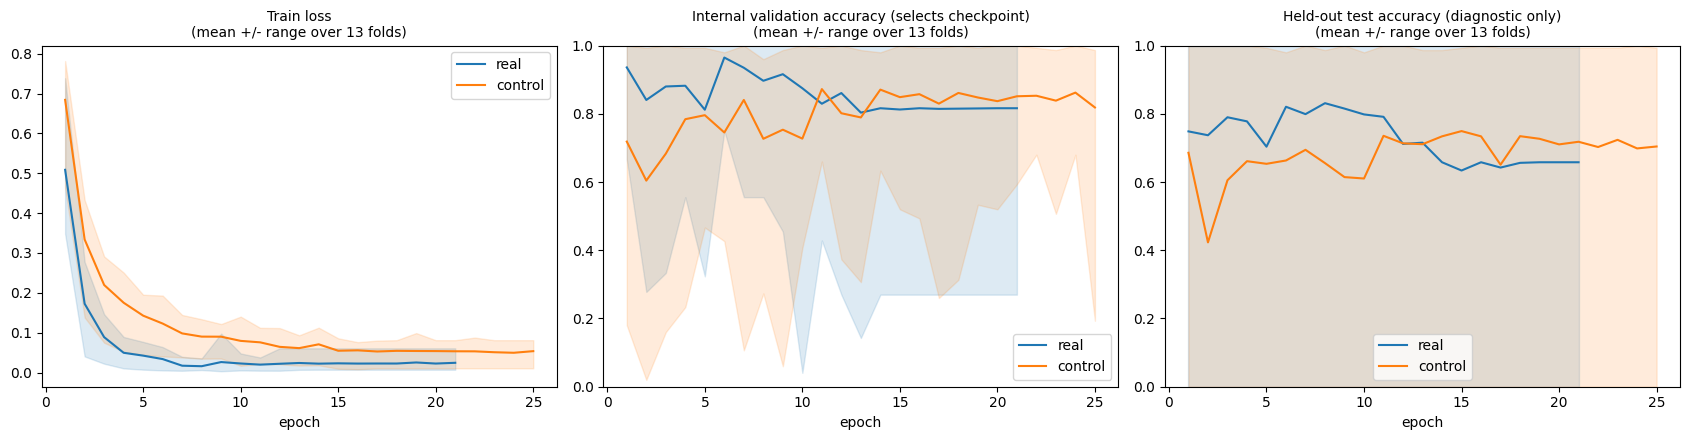

In [9]:
def stacked(history, key):
    max_len = max(len(h[key]) for h in history.values())
    padded = [h[key] + [h[key][-1]] * (max_len - len(h[key])) for h in history.values()]
    return np.array(padded)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
panels = [("train_loss", "Train loss"), ("val_acc", "Internal validation accuracy (selects checkpoint)"),
          ("test_acc", "Held-out test accuracy (diagnostic only)")]
for ax, (key, title) in zip(axes, panels):
    for hist, label, color in [(real_history, "real", "tab:blue"), (ctrl_history, "control", "tab:orange")]:
        arr = stacked(hist, key)
        mean, lo, hi = arr.mean(0), arr.min(0), arr.max(0)
        epochs = np.arange(1, arr.shape[1] + 1)
        ax.plot(epochs, mean, label=label, color=color)
        ax.fill_between(epochs, lo, hi, alpha=0.15, color=color)
    ax.set_xlabel("epoch"); ax.set_title(f"{title}\n(mean +/- range over 13 folds)", fontsize=10); ax.legend()
axes[1].set_ylim(0, 1); axes[2].set_ylim(0, 1)
plt.tight_layout()
plt.savefig(CKPT_DIR / "loso_training_curves.png", dpi=130, bbox_inches="tight")
plt.show()


## Results

Aggregated across all 13 held-out-patient folds. Read the per-class rows knowing that
`focal_aware` and `focal_to_bilateral_tonic_clonic` each have exactly one patient (§ intro) --
their fold could not have trained on that class at all.

In [10]:
def report(true, pred, subj_arr, tag):
    print(f"\n{'=' * 60}\n{tag} -- window-level (aggregated over all LOSO folds)\n{'=' * 60}")
    print(classification_report(true, pred, target_names=CLASS_NAMES, labels=list(range(N_CLASSES)), digits=3, zero_division=0))
    cm = confusion_matrix(true, pred, labels=list(range(N_CLASSES)))
    print("confusion matrix (rows=true, cols=predicted):")
    print(pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES))

    ev = pd.DataFrame({"subject": subj_arr, "true": true, "pred": pred})
    per_patient = ev.groupby("subject").apply(lambda g: (g.true == g.pred).mean(), include_groups=False)
    print(f"\n{tag} -- per-patient (event-level proxy) accuracy:")
    print(per_patient.rename("window_accuracy"))
    return cm, per_patient

real_cm, real_per_patient = report(real_true, real_pred, real_subj, "REAL")
ctrl_cm, ctrl_per_patient = report(ctrl_true, ctrl_pred, ctrl_subj, "ADVERSARIAL CONTROL")

real_acc = (real_true == real_pred).mean()
ctrl_acc = (ctrl_true == ctrl_pred).mean()
real_f1 = f1_score(real_true, real_pred, average="macro", zero_division=0)
ctrl_f1 = f1_score(ctrl_true, ctrl_pred, average="macro", zero_division=0)
print(f"\n{'=' * 60}\nSUMMARY\n{'=' * 60}")
print(f"real LOSO accuracy      : {real_acc:.3f}  (macro-F1 {real_f1:.3f})")
print(f"control LOSO accuracy   : {ctrl_acc:.3f}  (macro-F1 {ctrl_f1:.3f})  <- patient-recognition floor")
print(f"real - control          : {real_acc - ctrl_acc:+.3f}")
if real_acc <= ctrl_acc + 0.05:
    print("\n>>> The real result does not clearly clear the adversarial floor -- treat it as")
    print(">>> evidence the model is mostly recognising patients, not seizure subtype, given")
    print(">>> how few patients back two of the three classes.")



REAL -- window-level (aggregated over all LOSO folds)
                                 precision    recall  f1-score   support

                    focal_aware      0.000     0.000     0.000        45
       focal_impaired_awareness      0.906     0.989     0.946      1655
focal_to_bilateral_tonic_clonic      0.000     0.000     0.000       124

                       accuracy                          0.897      1824
                      macro avg      0.302     0.330     0.315      1824
                   weighted avg      0.822     0.897     0.858      1824

confusion matrix (rows=true, cols=predicted):
                                 focal_aware  focal_impaired_awareness  \
focal_aware                                0                        45   
focal_impaired_awareness                  15                      1637   
focal_to_bilateral_tonic_clonic            0                       124   

                                 focal_to_bilateral_tonic_clonic  
focal_aware          

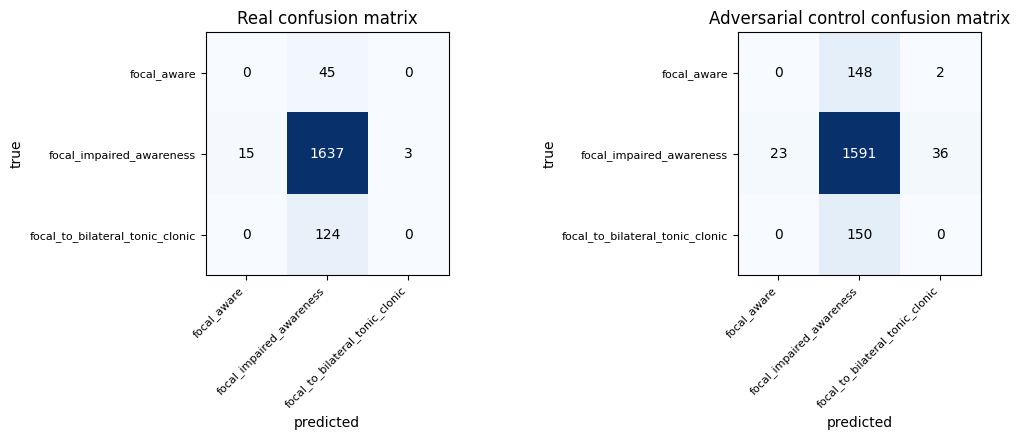


summary written to ..\checkpoints\stage2_subtype\loso_summary.json


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, cm, title in [(axes[0], real_cm, "Real"), (axes[1], ctrl_cm, "Adversarial control")]:
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(CLASS_NAMES, fontsize=8)
    ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(f"{title} confusion matrix")
    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.savefig(CKPT_DIR / "loso_confusion_matrices.png", dpi=130, bbox_inches="tight")
plt.show()

summary = {
    "real_accuracy": float(real_acc), "control_accuracy": float(ctrl_acc),
    "real_macro_f1": float(real_f1), "control_macro_f1": float(ctrl_f1),
    "n_patients": len(patients), "class_names": CLASS_NAMES,
    "patients_per_class": S2.groupby("subtype").subject.nunique().to_dict(),
}
(CKPT_DIR / "loso_summary.json").write_text(json.dumps(summary, indent=2))
print(f"\nsummary written to {CKPT_DIR / 'loso_summary.json'}")


## Notes

- **This LOSO result is not a claim of a working 3-class subtype classifier.** With 1 patient
  each behind two of the three classes, no split of this data can separate "learned the
  subtype" from "learned the patient" for those two classes -- more patients per minority
  class is what would fix this, not a different model or more epochs.
- Per-fold checkpoints (`checkpoints/stage2_subtype/{real,control}_fold_<patient>.pt`) now hold
  each fold's **best-internal-validation-epoch** weights, not the final epoch's -- reloading
  one does not require retraining or re-selecting a checkpoint.
- `focal_impaired_awareness` (11 patients) is the only class with enough patient diversity for
  its LOSO number to mean what LOSO is supposed to mean -- weight it accordingly against the
  other two rows in the classification report above.
- **What changed from the first version, and why:** internal-validation-based early stopping
  (replacing a blind fixed-epoch schedule), narrower model + heavier dropout/weight-decay
  (fighting the same overfitting Stage 1 showed, worse here given far less data per fold), and
  sqrt-inverse-frequency class weights (replacing a raw inverse-frequency weighting that could
  differ 30x+ between classes in a single fold). All three mirror specific issues found tuning
  `model_stage1_detection.ipynb` -- see that notebook's config cell and this one's for the
  parallel reasoning.